**Navigation:**  
[← Two-Population Structure](04_two_population.ipynb) | [Rt Decomposition](06_rt_wells_riley_decomposition.ipynb) | [Interventions →](07_interventions.ipynb)

# Superspreader Party Crawl: Cluster Re-seeding with General $R_0 < 1$

Goal:
- Keep the general population subcritical in isolation.
- Add high-transmission party clusters.
- Show sparse coupling can re-seed the general population with multiple cases.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from epi_structure import (
    DiseaseParameters,
    PopulationParameters,
    SimulationParameters,
    StructuredEpidemicModel,
    trajectory_to_df,
)

plt.style.use('seaborn-v0_8-darkgrid')

In [6]:
crawl_disease = DiseaseParameters(infectious_period=6.0, latent_period=2.5)

crawl_populations = [
    PopulationParameters(name='general', size=15_000, beta=0.0, initial_infected=8, disease=crawl_disease),
    PopulationParameters(name='party_a', size=300, beta=0.0, initial_infected=0, disease=crawl_disease),
    PopulationParameters(name='party_b', size=300, beta=0.0, initial_infected=0, disease=crawl_disease),
]

crawl_names = [p.name for p in crawl_populations]
crawl_sim = SimulationParameters(time_step=0.1, duration=180.0, output_stride=10)

# row=recipient, col=source
C_crawl = np.array([
    [0.0000065, 0.0000300, 0.0000300],
    [0.0000040, 0.0015000, 0.0002000],
    [0.0000040, 0.0002000, 0.0015000],
], dtype=float)

C_general_only = np.zeros_like(C_crawl)
C_general_only[0, 0] = C_crawl[0, 0]

In [7]:
crawl_traj = StructuredEpidemicModel(
    populations=crawl_populations,
    contact_matrix=C_crawl.tolist(),
    simulation=crawl_sim,
    intervention_plan=None,
).simulate()

general_only_traj = StructuredEpidemicModel(
    populations=crawl_populations,
    contact_matrix=C_general_only.tolist(),
    simulation=crawl_sim,
    intervention_plan=None,
).simulate()

df_crawl = trajectory_to_df(crawl_traj)
df_general_only = trajectory_to_df(general_only_traj)

N_crawl = np.array([p.size for p in crawl_populations], dtype=float)
gamma_crawl = np.array([1.0 / p.disease.infectious_period for p in crawl_populations], dtype=float)
K0_crawl = np.zeros_like(C_crawl)
for i in range(len(crawl_names)):
    for j in range(len(crawl_names)):
        K0_crawl[i, j] = C_crawl[i, j] * N_crawl[i] / gamma_crawl[j]

print('Superspreader crawl setup: K0 at full susceptibility')
print(pd.DataFrame(K0_crawl, index=crawl_names, columns=crawl_names).round(3))
print(f'\nGeneral-alone R (Kgg): {K0_crawl[0,0]:.3f} (< 1 expected)')
print(f'System-level R (spectral radius): {np.max(np.real(np.linalg.eigvals(K0_crawl))):.3f}')

Superspreader crawl setup: K0 at full susceptibility
         general  party_a  party_b
general    0.585     2.70     2.70
party_a    0.007     2.70     0.36
party_b    0.007     0.36     2.70

General-alone R (Kgg): 0.585 (< 1 expected)
System-level R (spectral radius): 3.076


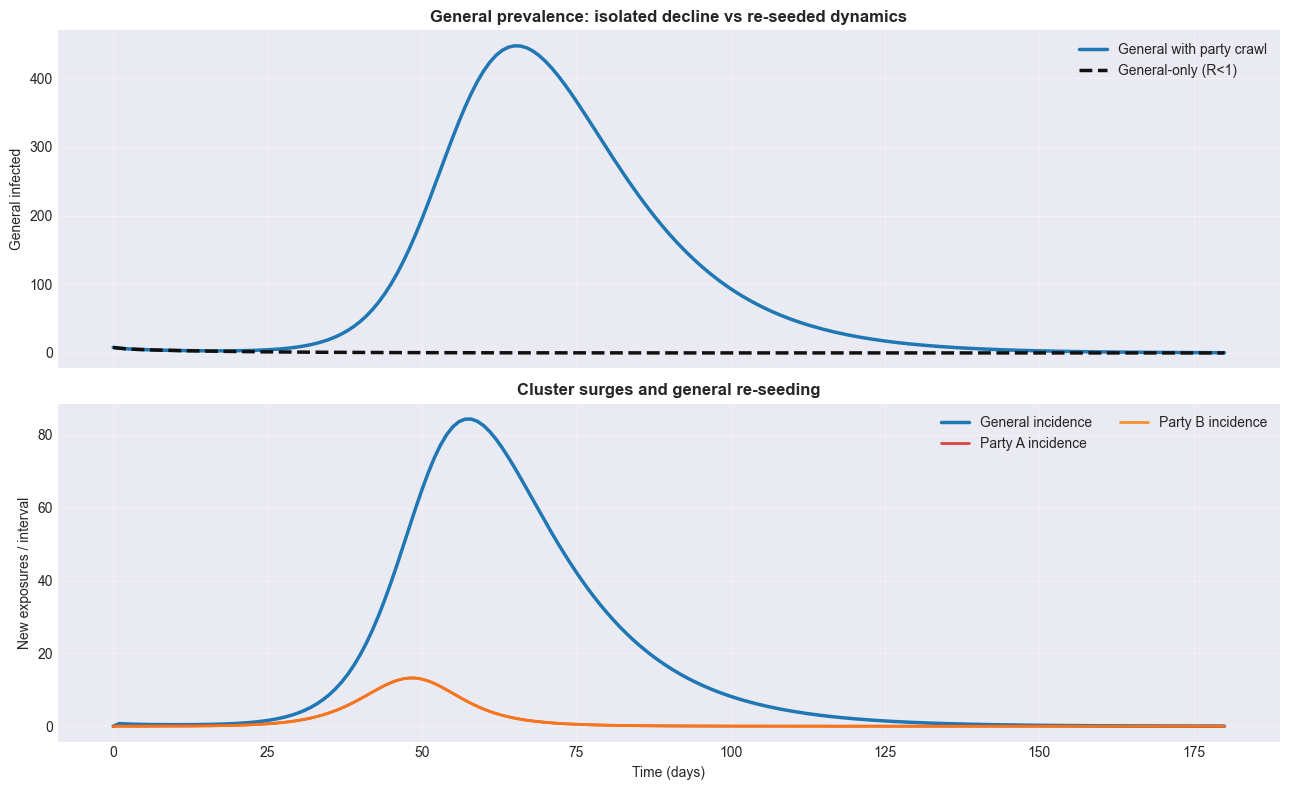


Key contrast:
  Peak general I with party crawl: 447.4
  Peak general I in isolated general-only world: 8.0
  Final general I with party crawl: 0.37
  Final general I in isolated world: 0.00


In [8]:
def pop(df_in: pd.DataFrame, name: str) -> pd.DataFrame:
    return df_in[df_in['population'] == name].copy()

g_crawl = pop(df_crawl, 'general')
g_iso = pop(df_general_only, 'general')
a_crawl = pop(df_crawl, 'party_a')
b_crawl = pop(df_crawl, 'party_b')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(g_crawl['time'], g_crawl['I'], linewidth=2.5, color='#1f77b4', label='General with party crawl')
axes[0].plot(g_iso['time'], g_iso['I'], linewidth=2.5, color='#111111', linestyle='--', label='General-only (R<1)')
axes[0].set_ylabel('General infected')
axes[0].set_title('General prevalence: isolated decline vs re-seeded dynamics', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(g_crawl['time'], g_crawl['new_exposed_interval'], linewidth=2.5, color='#1f77b4', label='General incidence')
axes[1].plot(a_crawl['time'], a_crawl['new_exposed_interval'], linewidth=2.0, color='#d62728', alpha=0.85, label='Party A incidence')
axes[1].plot(b_crawl['time'], b_crawl['new_exposed_interval'], linewidth=2.0, color='#ff7f0e', alpha=0.85, label='Party B incidence')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('New exposures / interval')
axes[1].set_title('Cluster surges and general re-seeding', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

print('\nKey contrast:')
print(f"  Peak general I with party crawl: {g_crawl['I'].max():.1f}")
print(f"  Peak general I in isolated general-only world: {g_iso['I'].max():.1f}")
print(f"  Final general I with party crawl: {g_crawl['I'].iloc[-1]:.2f}")
print(f"  Final general I in isolated world: {g_iso['I'].iloc[-1]:.2f}")